<a href="https://colab.research.google.com/github/kunphat510214-netizen/project6/blob/Project6/Project6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ขั้นตอนที่ 1 เข้าใจองค์กรของกลุ่ม
1. องค์กรนี้มีสิ่งของหลักอะไรบ้างที่ต้องเก็บข้อมูล?
ร้านกาแฟมี ”ออเดอร์เครื่องดื่ม“ เป็นสิ่งหลัก
2. แต่ละสิ่งของหลักนั้น มี "คุณสมบัติ" (ข้อมูล) อะไรบ้าง?
ออเดอร์มี : รหัสออเดอร์, ชื่อลูกค้า,ชื่อเมนู/ขนาด/ท็อปปิ้ง/ระดับความหวาน
3. แต่ละสิ่งของหลักนั้น ทำอะไรได้บ้าง?
ออเดอร์ “คำนวณราคา”ได้,ชื่อเมนู/ขนาด/ท็อปปิ้ง “เช็กว่าวัตถุดิบของเมนูหรือขนาดนั้นๆ หมดหรือยัง”ได้
4. ธุรกิจนี้มีการตัดสินใจหรือคำนวณอะไรที่ซับซ้อนกว่าการบวกเลขตรงตรงบ้าง?
การคำนวณที่ซับซ้อน:ราคาตามขนาดและท็อปปิ้ง (ขนาดใหญ่ +10 บาท/แก้ว, เปลี่ยนเป็นนมอัลมอนด์ +15 บาท/แก้ว)
 การคิดส่วนลดตามโปรโมชันหรือสมาชิก (เช่น สมาชิกสะสมแต้มครบ 10 แก้ว ฟรี 1 แก้ว)

In [ ]:
# ขั้นที่ 2: ออกแบบ Class ให้สอดคล้องกับกระบวนการหน้าร้าน
import random
import sqlite3
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print


class Member:
    def __init__(self, member_id, name, points=0):
        self.member_id = member_id
        self.name = name
        self.points = points

    def add_points(self, cups=1):
        self.points += cups
        return self.points


class DrinkOrder:
    BASE_PRICES = {
        "อเมริกาโน่": 45, "ลาเต้": 50, "คาปูชิโน่": 50,
        "เอสเพรสโซ่": 50, "มอคค่า": 50, "ชาเขียว": 45,
        "ชาไทย": 45, "มัทฉะลาเต้": 50, "ช็อกโกแลต": 50,
        "นมสด": 40, "สตรอว์เบอร์รี่โซดา": 40,
        "บลูฮาวายโซดา": 40, "ยูซุโซดา": 40,
    }
    TYPE_PRICES = {"ร้อน": 0, "เย็น": 5, "ปั่น": 10}
    SIZE_PRICES = {"S": 0, "M": 10, "L": 20}
    TOPPING_PRICES = {"ไม่มี": 0, "ไข่มุก": 5, "วิปครีม": 15, "ครีมชีส": 20, "เจลลี่": 5}
    PAYMENT_METHODS = ("เงินสด", "QR Code", "บัตร")

    def __init__(self, order_id, customer_name, menu_name, drink_type, size,
                 topping, sweetness_level, receive_type, member_id=None):
        self.order_id = order_id
        self.queue_no = f"Q{order_id:03d}"
        self.customer_name = customer_name
        self.menu_name = menu_name
        self.drink_type = drink_type
        self.size = size
        self.topping = topping
        self.sweetness_level = sweetness_level
        self.receive_type = receive_type
        self.member_id = member_id
        self.payment_method = None
        self.payment_status = "ยังไม่ชำระ"
        self.status = "รอชำระเงิน"
        self.wait_minutes = 0

    def calculate_subtotal(self):
        return (self.BASE_PRICES[self.menu_name]
                + self.TYPE_PRICES[self.drink_type]
                + self.SIZE_PRICES[self.size]
                + self.TOPPING_PRICES[self.topping])

    def calculate_price(self):
        # สมาชิกได้รับส่วนลด 5%
        discount_rate = 0.05 if self.member_id else 0
        return round(self.calculate_subtotal() * (1 - discount_rate), 2)

    def confirm_payment(self, payment_method):
        if payment_method not in self.PAYMENT_METHODS:
            raise ValueError("ช่องทางชำระเงินไม่ถูกต้อง")
        self.payment_method = payment_method
        self.payment_status = "ชำระแล้ว"
        self.status = "รอดำเนินการ"

    def receipt_text(self):
        return (f"ใบเสร็จ R{self.order_id:05d} | {self.queue_no} | "
                f"{self.menu_name} {self.drink_type} {self.size} | "
                f"{self.calculate_price():,.2f} บาท | {self.payment_method}")

    def sticker_text(self):
        return (f"{self.queue_no} {self.menu_name}/{self.drink_type}/{self.size} "
                f"หวาน {self.sweetness_level} ท็อปปิ้ง {self.topping} ({self.receive_type})")

    def to_record(self):
        return {
            "order_id": self.order_id,
            "queue_no": self.queue_no,
            "customer_name": self.customer_name,
            "member_id": self.member_id,
            "menu_name": self.menu_name,
            "drink_type": self.drink_type,
            "size": self.size,
            "topping": self.topping,
            "sweetness_level": self.sweetness_level,
            "receive_type": self.receive_type,
            "payment_method": self.payment_method,
            "subtotal": self.calculate_subtotal(),
            "price": self.calculate_price(),
            "wait_minutes": self.wait_minutes,
            "status": self.status,
        }


class QueueSystem:
    def __init__(self):
        self.active_orders = []
        self.events = []

    def _log(self, order, event):
        self.events.append({
            "event_id": len(self.events) + 1,
            "order_id": order.order_id,
            "event": event,
            "status": order.status,
        })

    def send_to_kds(self, order):
        if order.payment_status != "ชำระแล้ว":
            raise ValueError("ต้องยืนยันการชำระเงินก่อนส่งเข้า KDS")
        self.active_orders.append(order)
        order.status = "รอดำเนินการ"
        self._log(order, "ส่งเข้า KDS")

    def start_preparing(self, order):
        order.status = "กำลังทำ"
        self._log(order, "บาริสต้ารับออเดอร์")

    def call_queue(self, order, announce=False):
        order.status = "พร้อมรับ"
        self._log(order, "เรียกคิว")
        message = f"🔔 คิว {order.queue_no} พร้อมรับที่เคาน์เตอร์"
        if announce:
            print(message, "(เสียงเรียก)")
        return message

    def complete_order(self, order):
        order.status = "เสร็จสิ้น"
        self._log(order, "ส่งมอบสำเร็จ")
        self.active_orders = [o for o in self.active_orders if o.order_id != order.order_id]




In [ ]:
# ขั้นที่ 3: Function ช่วยงาน และสาธิต flow 10 ขั้นตามโจทย์
def generate_customer_name():
    first_names = ["เจสซี่", "ลีโอ", "มายา", "อเล็กซ์", "คลาร่า", "ลูคัส", "นิโคล"]
    last_names = ["รักเรียน", "ใจดี", "สายทอง", "รุ่งเรือง", "มั่นคง", "วงศ์สว่าง", "เจริญพร"]
    return f"{random.choice(first_names)} {random.choice(last_names)}"


def random_sweetness_level(levels=("0%", "25%", "50%", "75%", "100%")):
    return random.choice(levels)


def build_random_order(order_id, member=None):
    return DrinkOrder(
        order_id=order_id,
        customer_name=member.name if member else generate_customer_name(),
        menu_name=random.choice(list(DrinkOrder.BASE_PRICES)),
        drink_type=random.choice(list(DrinkOrder.TYPE_PRICES)),
        size=random.choice(list(DrinkOrder.SIZE_PRICES)),
        topping=random.choice(list(DrinkOrder.TOPPING_PRICES)),
        sweetness_level=random_sweetness_level(),
        receive_type=random.choice(["ทานที่ร้าน", "กลับบ้าน"]),
        member_id=member.member_id if member else None,
    )


demo_member = Member("M001", "มายา ใจดี", points=4)
demo_order = DrinkOrder(1, demo_member.name, "ลาเต้", "เย็น", "M", "วิปครีม",
                        "50%", "กลับบ้าน", demo_member.member_id)
demo_queue = QueueSystem()

print("1-3) รับลูกค้าและตัวเลือก:", demo_order.menu_name, demo_order.size,
      demo_order.topping, demo_order.sweetness_level, demo_order.receive_type,
      "สมาชิก" if demo_order.member_id else "ไม่เป็นสมาชิก")
print("4) สรุปราคา:", demo_order.calculate_price(), "บาท")
demo_order.confirm_payment("QR Code")
demo_member.add_points()
print("5) ชำระเงิน:", demo_order.payment_status, "ด้วย", demo_order.payment_method)
print("6)", demo_order.receipt_text())
print("   Sticker:", demo_order.sticker_text())
demo_queue.send_to_kds(demo_order)
print("7) KDS:", demo_order.status)
demo_queue.start_preparing(demo_order)
demo_queue.call_queue(demo_order, announce=True)
print("8-9) หน้าจอแสดง:", demo_order.queue_no, demo_order.status)
demo_queue.complete_order(demo_order)
print("10) สถานะ:", demo_order.status, "| คิวคงเหลือ:", len(demo_queue.active_orders))




1-3) รับลูกค้าและตัวเลือก: ลาเต้ M วิปครีม 50% กลับบ้าน สมาชิก
4) สรุปราคา: 76.0 บาท
5) ชำระเงิน: ชำระแล้ว ด้วย QR Code
6) ใบเสร็จ R00001 | Q001 | ลาเต้ เย็น M | 76.00 บาท | QR Code
   Sticker: Q001 ลาเต้/เย็น/M หวาน 50% ท็อปปิ้ง วิปครีม (กลับบ้าน)
7) KDS: รอดำเนินการ
🔔 คิว Q001 พร้อมรับที่เคาน์เตอร์ (เสียงเรียก)
8-9) หน้าจอแสดง: Q001 พร้อมรับ
10) สถานะ: เสร็จสิ้น | คิวคงเหลือ: 0


In [ ]:
# ขั้นที่ 4: จำลองธุรกรรมทีละรายการด้วย loop อย่างน้อย 300 รายการ
random.seed(612104)
members = {
    f"M{i:03d}": Member(f"M{i:03d}", generate_customer_name(), random.randint(0, 9))
    for i in range(1, 61)
}
queue_system = QueueSystem()
orders = []

for i in range(1, 301):
    member = random.choice(list(members.values())) if random.random() < 0.40 else None
    order = build_random_order(i, member)
    order.confirm_payment(random.choice(DrinkOrder.PAYMENT_METHODS))
    if member:
        member.add_points()

    queue_system.send_to_kds(order)
    queue_system.start_preparing(order)
    order.wait_minutes = random.randint(2, 18)
    queue_system.call_queue(order)
    queue_system.complete_order(order)
    orders.append(order)

assert len(orders) == 300
assert len(queue_system.active_orders) == 0
print(f"จำลองครบ {len(orders)} ออเดอร์ และส่งมอบทุกคิวเรียบร้อย")




จำลองครบ 300 ออเดอร์ และส่งมอบทุกคิวเรียบร้อย


In [ ]:
# ขั้นที่ 5-6: บันทึก CSV และฐานข้อมูล SQLite 3 ตาราง
records = [order.to_record() for order in orders]
df = pd.DataFrame(records)
df.to_csv("coffee_orders.csv", index=False, encoding="utf-8-sig")

members_df = pd.DataFrame([
    {"member_id": member.member_id, "member_name": member.name, "points": member.points}
    for member in members.values()
])
events_df = pd.DataFrame(queue_system.events)

conn = sqlite3.connect("coffee_shop.db")
df.to_sql("orders", conn, if_exists="replace", index=False)
members_df.to_sql("members", conn, if_exists="replace", index=False)
events_df.to_sql("order_events", conn, if_exists="replace", index=False)
print("บันทึก coffee_orders.csv และ coffee_shop.db สำเร็จ")
display(df.head())




บันทึก coffee_orders.csv และ coffee_shop.db สำเร็จ


,order_id,queue_no,customer_name,member_id,menu_name,drink_type,size,topping,sweetness_level,receive_type,payment_method,subtotal,price,wait_minutes,status
0,1,Q001,ลีโอ สายทอง,None,อเมริกาโน่,เย็น,M,ไข่มุก,0%,ทานที่ร้าน,บัตร,65,65.0,15,เสร็จสิ้น
1,2,Q002,ลีโอ รักเรียน,M026,ลาเต้,ร้อน,L,ครีมชีส,100%,กลับบ้าน,บัตร,90,85.5,12,เสร็จสิ้น
2,3,Q003,นิโคล มั่นคง,M018,คาปูชิโน่,ปั่น,S,ไม่มี,50%,ทานที่ร้าน,บัตร,60,57.0,3,เสร็จสิ้น
3,4,Q004,ลูคัส มั่นคง,M047,มัทฉะลาเต้,เย็น,M,วิปครีม,0%,กลับบ้าน,เงินสด,80,76.0,2,เสร็จสิ้น
4,5,Q005,อเล็กซ์ รักเรียน,None,มัทฉะลาเต้,ปั่น,S,ไม่มี,75%,ทานที่ร้าน,บัตร,60,60.0,11,เสร็จสิ้น


In [ ]:
# ขั้นที่ 7: โหลด CSV กลับมา สำรวจ และวิเคราะห์ด้วย pandas
coffee_df = pd.read_csv("coffee_orders.csv")
coffee_df.info()
display(coffee_df.describe(include="all"))

menu_summary = (coffee_df.groupby("menu_name")
                .agg(total_orders=("order_id", "count"),
                     total_revenue=("price", "sum"),
                     avg_price=("price", "mean"),
                     avg_wait_minutes=("wait_minutes", "mean"))
                .reset_index()
                .sort_values("total_revenue", ascending=False))
top5_menu = menu_summary.head(5)
display(top5_menu)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         300 non-null    int64  
 1   queue_no         300 non-null    object 
 2   customer_name    300 non-null    object 
 3   member_id        125 non-null    object 
 4   menu_name        300 non-null    object 
 5   drink_type       300 non-null    object 
 6   size             300 non-null    object 
 7   topping          300 non-null    object 
 8   sweetness_level  300 non-null    object 
 9   receive_type     300 non-null    object 
 10  payment_method   300 non-null    object 
 11  subtotal         300 non-null    int64  
 12  price            300 non-null    float64
 13  wait_minutes     300 non-null    int64  
 14  status           300 non-null    object 
dtypes: float64(1), int64(3), object(11)
memory usage: 35.3+ KB


,order_id,queue_no,customer_name,member_id,menu_name,drink_type,size,topping,sweetness_level,receive_type,payment_method,subtotal,price,wait_minutes,status
count,300.000000,300,300,125,300,300,300,300,300,300,300,300.000000,300.000000,300.000000,300
unique,NaN,300,49,56,13,3,3,5,5,2,3,NaN,NaN,NaN,1
top,NaN,Q300,อเล็กซ์ ใจดี,M006,นมสด,ร้อน,S,ครีมชีส,100%,ทานที่ร้าน,บัตร,NaN,NaN,NaN,เสร็จสิ้น
freq,NaN,1,14,6,31,112,114,67,71,152,106,NaN,NaN,NaN,300
mean,150.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.616667,67.214167,10.206667,NaN
std,86.746758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.775514,12.772161,4.840322,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,38.000000,2.000000,NaN
25%,75.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,57.000000,6.000000,NaN
50%,150.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.000000,66.500000,10.000000,NaN
75%,225.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,76.000000,15.000000,NaN


,menu_name,total_orders,total_revenue,avg_price,avg_wait_minutes
9,ลาเต้,29,2031.00,70.034483,9.344828
4,นมสด,31,1972.50,63.629032,9.774194
6,มอคค่า,27,1931.75,71.546296,8.962963
11,อเมริกาโน่,28,1917.75,68.491071,10.892857
0,คาปูชิโน่,23,1643.75,71.467391,10.304348



 ออเดอร์ราคาสูง


,order_id,queue_no,menu_name,price
0,41,Q041,ช็อกโกแลต,100.0
1,198,Q198,เอสเพรสโซ่,100.0
2,21,Q021,อเมริกาโน่,95.0
3,168,Q168,ลาเต้,95.0
4,186,Q186,ช็อกโกแลต,95.0



 QR กลับบ้าน


,order_id,menu_name,receive_type,payment_method,price
0,9,มัทฉะลาเต้,กลับบ้าน,QR Code,70.00
1,20,คาปูชิโน่,กลับบ้าน,QR Code,55.00
2,22,คาปูชิโน่,กลับบ้าน,QR Code,85.00
3,26,สตรอว์เบอร์รี่โซดา,กลับบ้าน,QR Code,76.00
4,31,นมสด,กลับบ้าน,QR Code,52.25



 คิวรอนาน


...


 รายได้ตามช่องทางชำระ


,payment_method,total_orders,total_revenue,avg_price
0,บัตร,106,7118.75,67.16
1,เงินสด,101,6808.50,67.41
2,QR Code,93,6237.00,67.06



 JOIN สมาชิกกับออเดอร์


,order_id,queue_no,member_name,menu_name,price
0,197,Q197,มายา สายทอง,มอคค่า,90.25
1,241,Q241,ลูคัส มั่นคง,ลาเต้,90.25
2,264,Q264,ลีโอ รักเรียน,คาปูชิโน่,90.25
3,2,Q002,ลีโอ รักเรียน,ลาเต้,85.50
4,88,Q088,คลาร่า วงศ์สว่าง,มอคค่า,85.50


/tmp/ipykernel_1201/471932621.py:47: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1201/471932621.py:47: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1201/471932621.py:47: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1201/471932621.py:47: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1201/471932621.py:47: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1201/471932621.py:47: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1201/471932621.py:47: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_

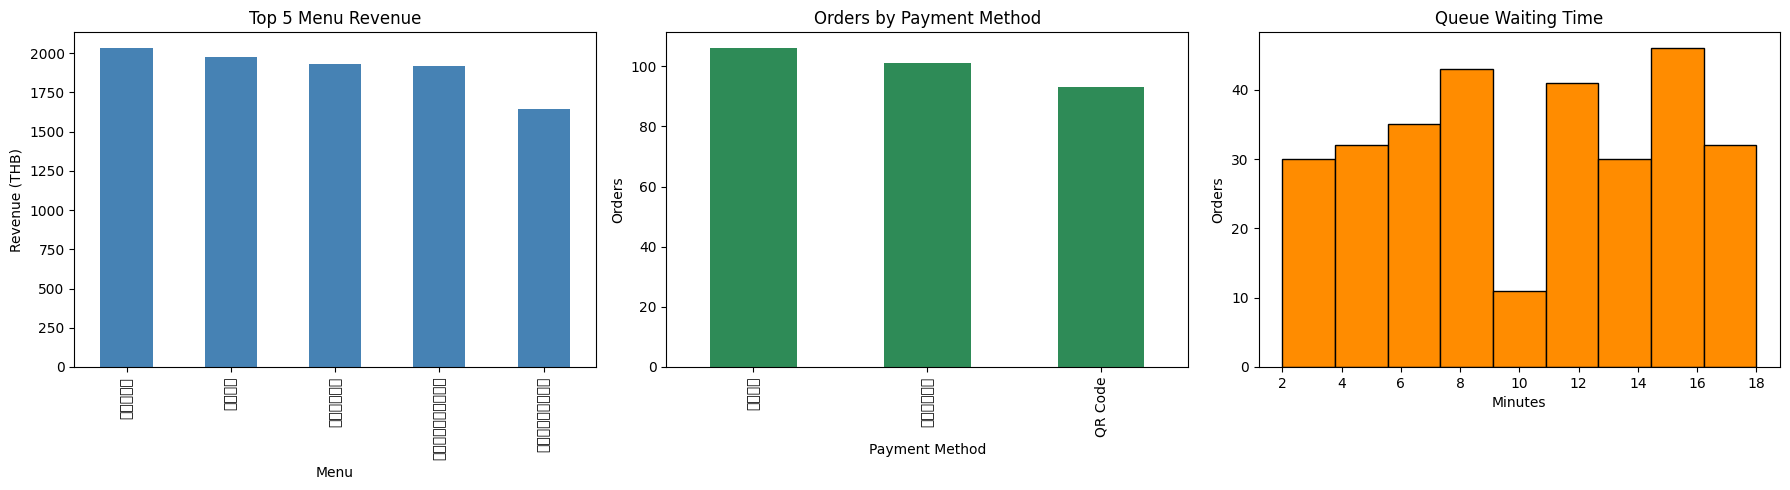

สรุปผล: เมนูที่สร้างรายได้สูงสุดคือ ลาเต้ รวม 2,031.00 บาท
ลูกค้าสมาชิกคิดเป็น 41.7% ของออเดอร์ทั้งหมด
ช่องทางชำระเงินที่ใช้มากที่สุดคือ บัตร
เวลารอเฉลี่ยอยู่ที่ 10.2 นาที
ร้านควรเตรียมวัตถุดิบของเมนูยอดนิยมและจัดกำลังคนในช่วงที่คิวรอนาน


In [ ]:
# ขั้นที่ 7-8: SQL อย่างน้อย 3 query, GROUP BY, JOIN, กราฟ 3 แบบ และสรุปผล
queries = {
    "ออเดอร์ราคาสูง": """
        SELECT order_id, queue_no, menu_name, price
        FROM orders WHERE price >= 75
        ORDER BY price DESC LIMIT 5
    """,
    "QR กลับบ้าน": """
        SELECT order_id, menu_name, receive_type, payment_method, price
        FROM orders WHERE receive_type = 'กลับบ้าน' AND payment_method = 'QR Code'
        ORDER BY order_id LIMIT 5
    """,
    "คิวรอนาน": """
        SELECT order_id, menu_name, wait_minutes
        FROM orders WHERE wait_minutes >= 15
        ORDER BY wait_minutes DESC, order_id LIMIT 5
    """,
    "รายได้ตามช่องทางชำระ": """
        SELECT payment_method, COUNT(*) AS total_orders,
               ROUND(SUM(price), 2) AS total_revenue,
               ROUND(AVG(price), 2) AS avg_price
        FROM orders GROUP BY payment_method
        ORDER BY total_revenue DESC
    """,
    "JOIN สมาชิกกับออเดอร์": """
        SELECT o.order_id, o.queue_no, m.member_name, o.menu_name, o.price
        FROM orders o JOIN members m ON o.member_id = m.member_id
        WHERE o.price >= 60 ORDER BY o.price DESC LIMIT 5
    """,
}

for title, query in queries.items():
    print("\n", title)
    display(pd.read_sql_query(query, conn))

payment_counts = coffee_df["payment_method"].value_counts()
if plt is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    top5_menu.plot.bar(x="menu_name", y="total_revenue", ax=axes[0], legend=False, color="steelblue")
    axes[0].set(title="Top 5 Menu Revenue", xlabel="Menu", ylabel="Revenue (THB)")

    payment_counts.plot.bar(ax=axes[1], color="seagreen")
    axes[1].set(title="Orders by Payment Method", xlabel="Payment Method", ylabel="Orders")

    coffee_df["wait_minutes"].plot.hist(bins=9, ax=axes[2], color="darkorange", edgecolor="black")
    axes[2].set(title="Queue Waiting Time", xlabel="Minutes", ylabel="Orders")
    plt.tight_layout()
    plt.show()

best_menu = menu_summary.iloc[0]
member_share = coffee_df["member_id"].notna().mean() * 100
popular_payment = payment_counts.index[0]
print(f"สรุปผล: เมนูที่สร้างรายได้สูงสุดคือ {best_menu['menu_name']} "
      f"รวม {best_menu['total_revenue']:,.2f} บาท")
print(f"ลูกค้าสมาชิกคิดเป็น {member_share:.1f}% ของออเดอร์ทั้งหมด")
print(f"ช่องทางชำระเงินที่ใช้มากที่สุดคือ {popular_payment}")
print(f"เวลารอเฉลี่ยอยู่ที่ {coffee_df['wait_minutes'].mean():.1f} นาที")
print("ร้านควรเตรียมวัตถุดิบของเมนูยอดนิยมและจัดกำลังคนในช่วงที่คิวรอนาน")

conn.close()
